# ⚛️ Introdução à Computação Quântica: Fundamentos e Algoritmos Práticos
### Caderno Interativo de Implementação (Google Colab)
**Autor:** Felipe Junqueira Leite | **Orientador:** Prof. Dr. André Martin Timpanaro  
**Instituição:** Universidade Federal do ABC (UFABC) / CMCC  

---
👋 **Bem-vindo ao laboratório prático de Computação Quântica!**  
Este caderno foi projetado para que **qualquer pessoa — de iniciantes a estudantes e entusiastas —** possa rodar circuitos quânticos reais, visualizar gráficos e compreender a física e a computação quântica de forma simples, intuitiva e rigorosa.

Cada bloco possui:
- 💡 **Analogias claras** (moedas no ar, dados mágicos conectados, relógios modulares e prismas).
- 🧩 **Códigos fáceis e autoexplicativos** com nomes de variáveis em português claro.
- 📊 **Visualização gráfica imediata** (circuitos desenhados e histogramas de probabilidade).
- 📖 **Fontes bibliográficas oficiais** (livros de referência como *Nielsen & Chuang* e *IBM Quantum Docs*).

Basta clicar no botão de **"Play" (▶)** ao lado de cada célula para executar!

In [ ]:
# ==============================================================================
# PASSO 0: INSTALAÇÃO DAS FERRAMENTAS QUÂNTICAS
# ==============================================================================
# Instalamos o Qiskit (o framework quântico da IBM) e o Qiskit Aer (nosso simulador).
# O parâmetro "-q" significa quiet (instala silenciosamente sem poluir a tela).

!pip install qiskit qiskit-aer pylatexenc matplotlib -q

print("✅ Ambiente Quântico configurado com sucesso! Pronto para começar.")

# 📖 Fonte: IBM Quantum Documentation (https://quantum.cloud.ibm.com/docs/)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.6 MB/s eta 0:00:00
✅ Ambiente Quântico configurado com sucesso! Pronto para começar.


---
# 🔔 1. Estados de Bell: O Fundamento do Emaranhamento Quântico

Imagine dois dados mágicos: quando você joga o primeiro dado no Brasil e ele cai no número **6**, o segundo dado jogado no Japão cai **instantaneamente no número 6**, como se estivessem conectados por um fio invisível!  
Isso é o **emaranhamento quântico**!

Existem 4 combinações fundamentais desse par mágico, chamados de **Estados de Bell**:
1. $|\Phi^+\rangle$: Gêmeos idênticos (00 ou 11 com mesma fase).
2. $|\Phi^-\rangle$: Gêmeos com fase invertida (00 ou 11 com oposição de fase no |11>).
3. $|\Psi^+\rangle$: Opostos simétricos (se um é 0, o outro é 1: 01 ou 10).
4. $|\Psi^-\rangle$: Opostos totais / Estado Singleto (01 ou 10 com fase negativa).

🎯 Resultados da Medição: {'11': 509, '00': 515}
💡 Observe: Apenas '00' (~50%) e '11' (~50%) aparecem. Sincronização quântica total!


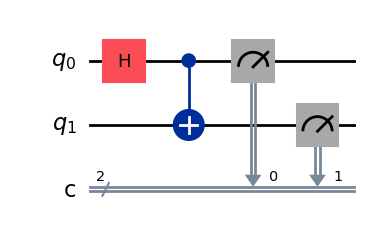

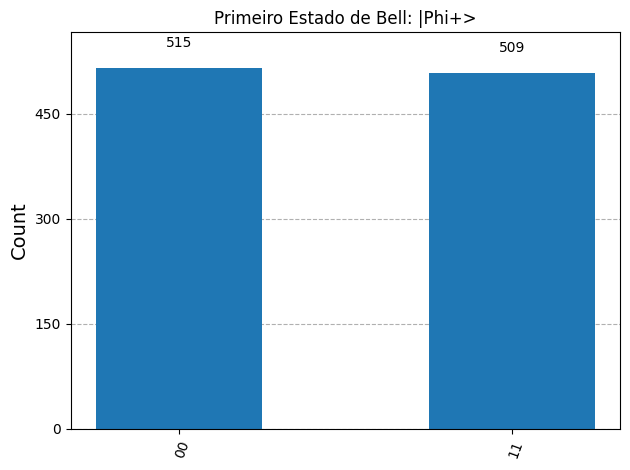

In [ ]:
# ==============================================================================
# PRIMEIRO ESTADO DE BELL: |Phi+> = (|00> + |11>) / sqrt(2)
# "Gêmeos Perfeitos: Se medir 0 no primeiro, o segundo será 0. Se medir 1, será 1!"
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# PASSO 1: Criamos um circuito com 2 qubits e 2 bits clássicos (para armazenar a medição)
circuito_bell_1 = QuantumCircuit(2, 2)

# PASSO 2: Colocamos o qubit 0 em SUPERPOSIÇÃO (porta Hadamard, como moeda girando no ar)
circuito_bell_1.h(0)

# PASSO 3: Criamos o EMARANHAMENTO usando a porta CNOT (conecta o qubit 0 ao qubit 1)
circuito_bell_1.cx(0, 1)

# PASSO 4: Realizamos a MEDIÇÃO (colapso da função de onda)
circuito_bell_1.measure([0, 1], [0, 1])

# PASSO 5: Simulação com 1024 execuções (shots)
simulador = AerSimulator()
circuito_compilado = transpile(circuito_bell_1, simulador)
resultados = simulador.run(circuito_compilado, shots=1024).result().get_counts()

print("🎯 Resultados da Medição:", resultados)
print("💡 Observe: Apenas '00' (~50%) e '11' (~50%) aparecem. Sincronização quântica total!")

display(circuito_bell_1.draw('mpl'))
display(plot_histogram(resultados, title="Primeiro Estado de Bell: |Phi+>"))

# 📖 Fonte: Nielsen, M. A., & Chuang, I. L. (2010). Quantum Computation and Quantum Information, Cap. 1, pág. 25.


🎯 Resultados da Medição: {'00': 483, '11': 541}
💡 A fase negativa (-) fica guardada no plano quântico sem alterar as probabilidades de 50%/50%.


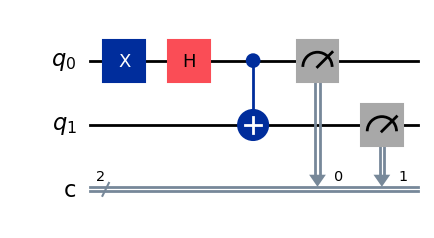

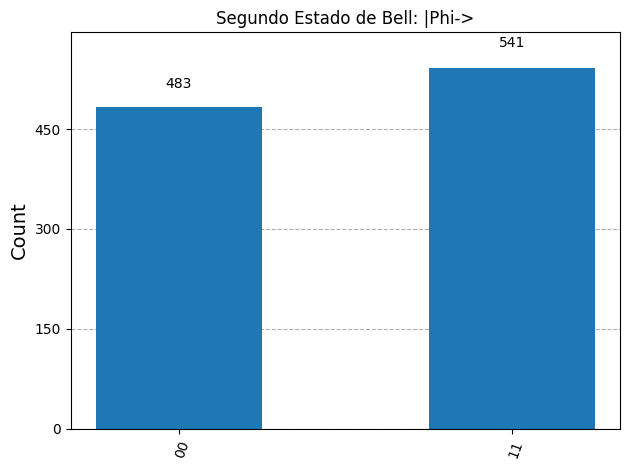

In [ ]:
# ==============================================================================
# SEGUNDO ESTADO DE BELL: |Phi-> = (|00> - |11>) / sqrt(2)
# "Gêmeos com Fase Invertida: Igual ao anterior, mas com sinal negativo no |11>"
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

circuito_bell_2 = QuantumCircuit(2, 2)

# PASSO 1: Invertemos o qubit 0 para o estado |1> usando a porta NOT (X)
circuito_bell_2.x(0)

# PASSO 2: Aplicamos Hadamard para criar superposição com fase relativa negativa
circuito_bell_2.h(0)

# PASSO 3: Emaranhamos com a porta CNOT
circuito_bell_2.cx(0, 1)

# PASSO 4: Medição
circuito_bell_2.measure([0, 1], [0, 1])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_bell_2, simulador), shots=1024).result().get_counts()

print("🎯 Resultados da Medição:", resultados)
print("💡 A fase negativa (-) fica guardada no plano quântico sem alterar as probabilidades de 50%/50%.")

display(circuito_bell_2.draw('mpl'))
display(plot_histogram(resultados, title="Segundo Estado de Bell: |Phi->"))

# 📖 Fonte: Nielsen & Chuang (2010), Seção 1.3.6 (Bell States).


🎯 Resultados da Medição: {'10': 479, '01': 545}
💡 Apenas '01' e '10' aparecem (~50% cada). Anti-correlação perfeita!


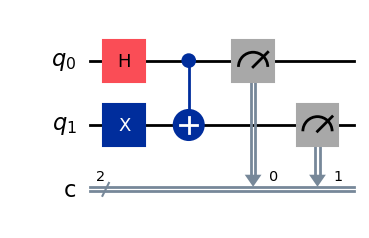

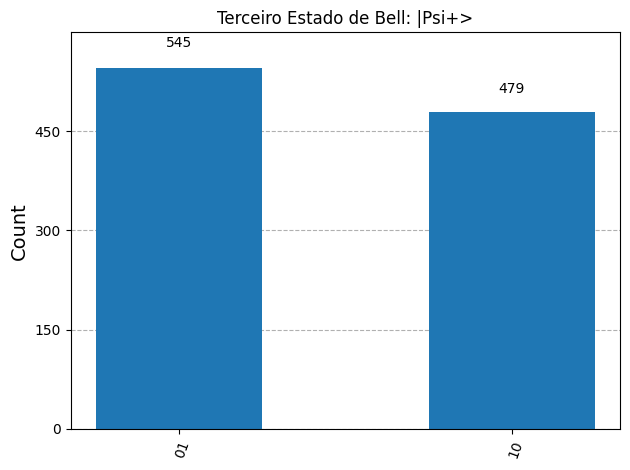

In [ ]:
# ==============================================================================
# TERCEIRO ESTADO DE BELL: |Psi+> = (|01> + |10>) / sqrt(2)
# "Opostos Perfeitos: Se um qubit for 0, o outro OBRIGATORIAMENTE será 1!"
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

circuito_bell_3 = QuantumCircuit(2, 2)

# PASSO 1: Invertemos o qubit alvo (qubit 1) para o estado |1>
circuito_bell_3.x(1)

# PASSO 2: Superposição no qubit 0
circuito_bell_3.h(0)

# PASSO 3: Emaranhamento com CNOT
circuito_bell_3.cx(0, 1)

# PASSO 4: Medição
circuito_bell_3.measure([0, 1], [0, 1])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_bell_3, simulador), shots=1024).result().get_counts()

print("🎯 Resultados da Medição:", resultados)
print("💡 Apenas '01' e '10' aparecem (~50% cada). Anti-correlação perfeita!")

display(circuito_bell_3.draw('mpl'))
display(plot_histogram(resultados, title="Terceiro Estado de Bell: |Psi+>"))

# 📖 Fonte: Nielsen & Chuang (2010), Cap. 1.


In [ ]:
# ==============================================================================
# QUARTO ESTADO DE BELL: |Psi-> = (|01> - |10>) / sqrt(2)
# "O Estado Singleto: Opostos perfeitos com diferença de fase quântica"
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

circuito_bell_4 = QuantumCircuit(2, 2)

# PASSO 1: Invertemos AMBOS os qubits para |11>
circuito_bell_4.x(0)
circuito_bell_4.x(1)

# PASSO 2: Superposição com fase no qubit 0
circuito_bell_4.h(0)

# PASSO 3: Emaranhamento
circuito_bell_4.cx(0, 1)

# PASSO 4: Medição
circuito_bell_4.measure([0, 1], [0, 1])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_bell_4, simulador), shots=1024).result().get_counts()

print("🎯 Resultados da Medição:", resultados)
print("💡 O estado singleto é simétrico e preserva suas propriedades sob qualquer rotação de base.")

display(circuito_bell_4.draw('mpl'))
display(plot_histogram(resultados, title="Quarto Estado de Bell (Singleto): |Psi->"))

# 📖 Fonte: Nielsen & Chuang (2010), Seção 1.3.6.


---
# 🌐 2. Estado GHZ: Emaranhamento Multipartido (3 Qubits)

O que acontece se conectarmos **três partículas quânticas** ao mesmo tempo?  
Criamos o **Estado GHZ** (Greenberger-Horne-Zeilinger):
$$|\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$

Se qualquer um dos 3 qubits for medido e cair em `0`, **todos os outros dois imediatamente se tornam `0`**. Se for `1`, **todos viram `1`**!

In [ ]:
# ==============================================================================
# ESTADO GHZ: Emaranhamento em Cascata com 3 Qubits
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# PASSO 1: Criamos o circuito com 3 qubits e 3 bits clássicos
circuito_ghz = QuantumCircuit(3, 3)

# PASSO 2: Superposição inicial no qubit 0
circuito_ghz.h(0)

# PASSO 3: Propagação do emaranhamento em CASCATA
# Qubit 0 emaranha com o Qubit 1:
circuito_ghz.cx(0, 1)
# Qubit 1 (já emaranhado) agora emaranha com o Qubit 2:
circuito_ghz.cx(1, 2)

# PASSO 4: Medição dos 3 qubits
circuito_ghz.measure([0, 1, 2], [0, 1, 2])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_ghz, simulador), shots=1024).result().get_counts()

print("🎯 Resultados do Estado GHZ:", resultados)
print("💡 Apenas '000' (~50%) e '111' (~50%) aparecem!")

display(circuito_ghz.draw('mpl'))
display(plot_histogram(resultados, title="Estado GHZ: Emaranhamento de 3 Qubits"))

# 📖 Fonte: Greenberger, D. M., Horne, M. A., & Zeilinger, A. (1989). Going beyond Bell's Theorem.


---
# 🎛️ 3. Sub-rotinas e Operações Controladas: O "IF" Quântico

Na programação comum, usamos comandos condicionais como `if (condição) { faz algo }`.  
Na computação quântica, podemos condicionar um circuito inteiro a um **qubit de controle**.  
Se o controle estiver em superposição, o circuito cria um estado quântico condicional modular!

In [ ]:
# ==============================================================================
# SUB-ROTINA CONTROLADA: O "IF QUÂNTICO"
# "Se o Qubit de Controle for 1, prepara um Estado de Bell nos qubits 1 e 2"
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# PASSO 1: Criamos a sub-rotina independente (preparação de Bell de 2 qubits)
subrotina_bell = QuantumCircuit(2, name="Prepara_Bell")
subrotina_bell.h(0)
subrotina_bell.cx(0, 1)

# PASSO 2: Transformamos a sub-rotina em uma PORTA CONTROLADA (.control(1))
porta_bell_controlada = subrotina_bell.to_gate().control(1)

# PASSO 3: Montamos o circuito principal de 3 qubits
circuito_principal = QuantumCircuit(3, 3)

# Colocamos o qubit de controle (qubit 0) em superposição
circuito_principal.h(0)

# Aplicamos a sub-rotina: qubit 0 controla, qubits 1 e 2 recebem a ação
circuito_principal.append(porta_bell_controlada, [0, 1, 2])

# Decompomos para permitir a simulação e medimos
circuito_simulado = circuito_principal.decompose()
circuito_simulado.measure([0, 1, 2], [0, 1, 2])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_simulado, simulador), shots=1024).result().get_counts()

print("🎯 Resultados da Sub-rotina Controlada:", resultados)
print("💡 '000' aparece 50% das vezes (quando o controle colapsou para 0).")
print("💡 '100' e '111' aparecem 25% cada (quando o controle colapsou para 1 e ativou o Bell).")

display(circuito_principal.draw('mpl'))
display(plot_histogram(resultados, title="Execução Condicional Quântica"))

# 📖 Fonte: Nielsen & Chuang (2010), Cap. 4 (Quantum Circuits).


---
# 🧪 4. Desigualdade CHSH: Prova Experimental da Não-Localidade

Albert Einstein acreditava que a mecânica quântica era incompleta e que as partículas possuíam "variáveis ocultas locais".  
John Bell e os pesquisadores Clauser, Horne, Shimony e Holt (CHSH) demonstraram matematicamente:
- Se a física clássica de Einstein for verdadeira: $|S| \le 2.0$
- Se a mecânica quântica for verdadeira: $S$ pode chegar até $2\sqrt{2} \approx 2.828$!

Vamos rodar a simulação e verificar a quebra do limite clássico!

In [ ]:
# ==============================================================================
# TESTE DA DESIGUALDADE CHSH: QUEBRANDO O LIMITE CLÁSSICO DE S <= 2
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import numpy as np

def construir_circuito_chsh(angulo_alice, angulo_bob):
    """Cria um par emaranhado de Bell e gira os detectores de Alice e Bob nos ângulos especificados."""
    circuito = QuantumCircuit(2, 2)
    # 1. Prepara Estado de Bell |Phi+>
    circuito.h(0)
    circuito.cx(0, 1)
    # 2. Rotações das bases de medição (simula os detectores girando no espaço)
    circuito.ry(angulo_alice, 0)
    circuito.ry(angulo_bob, 1)
    circuito.measure([0, 1], [0, 1])
    return circuito

# Ângulos ótimos que maximizam a quebra quântica
angulo_alice_Z = 0
angulo_alice_X = np.pi / 2
angulo_bob_W = np.pi / 4
angulo_bob_V = -np.pi / 4

# 4 combinações de medições entre Alice e Bob
circuitos_chsh = [
    construir_circuito_chsh(angulo_alice_Z, angulo_bob_W),
    construir_circuito_chsh(angulo_alice_Z, angulo_bob_V),
    construir_circuito_chsh(angulo_alice_X, angulo_bob_W),
    construir_circuito_chsh(angulo_alice_X, angulo_bob_V)
]

simulador = AerSimulator()
correlacoes_E = []

for circ in circuitos_chsh:
    contagens = simulador.run(transpile(circ, simulador), shots=8192).result().get_counts()
    iguais = contagens.get("00", 0) + contagens.get("11", 0)
    diferentes = contagens.get("01", 0) + contagens.get("10", 0)
    total = iguais + diferentes
    # Correlação E = P(iguais) - P(diferentes)
    E = (iguais - diferentes) / total
    correlacoes_E.append(E)

# Parâmetro CHSH: S = E(A,B) - E(A,B') + E(A',B) + E(A',B')
parametro_S = correlacoes_E[0] - correlacoes_E[1] + correlacoes_E[2] + correlacoes_E[3]

print(f"📊 Parâmetro S medido:               {parametro_S:.4f}")
print("🔒 Limite Máximo da Física Clássica:  2.0000")
print(f"🌌 Limite Máximo Quântico (Tsirelson): {2 * np.sqrt(2):.4f}")

if parametro_S > 2.0:
    print("\n🎉 SUCESSO! O limite clássico foi violado (S > 2.0).")
    print("O emaranhamento quântico não pode ser explicado por teorias clássicas!")

# 📖 Fonte: Clauser, J. F., Horne, M. A., Shimony, A., & Holt, R. A. (1969). Phys. Rev. Lett. 23, 880.


---
# 🔍 5. Algoritmo de Grover: Busca em Dados Não Estruturados

Imagine procurar um número secreto entre **16 opções** (de 0 a 15, em 4 qubits):
- Um computador clássico precisaria testar, em média, **8 tentativas**.
- O algoritmo de Grover encontra a resposta com altíssima certeza em apenas **3 passos**!

O algoritmo combina duas etapas geométricas:
1. **Oráculo ($U_\omega$):** Marca o item vencedor invertendo seu sinal ($-\ket{\omega}$).
2. **Difusor ($U_s$):** Inverte todas as amplitudes em torno da média, fazendo a probabilidade da resposta correta disparar!

In [ ]:
# ==============================================================================
# ALGORITMO DE GROVER: Busca pelo estado secreto |0101> (número 5) em 4 Qubits
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import ZGate
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# PASSO 1: Construção do Oráculo que reconhece o segredo |0101>
oraculo = QuantumCircuit(4, name="Oraculo (Marca 5)")
# Invertemos os bits que são 0 no segredo (posições 0 e 2)
oraculo.x([0, 2])
# Porta Z multi-controlada (aplica -1 se todos forem 1)
porta_mcz = ZGate().control(3)
oraculo.append(porta_mcz, [0, 1, 2, 3])
# Descomputação para não deixar lixo quântico
oraculo.x([0, 2])

# PASSO 2: Construção do Difusor (Reflexão de Householder em torno da média)
difusor = QuantumCircuit(4, name="Difusor (Inversão)")
difusor.h([0, 1, 2, 3])
difusor.x([0, 1, 2, 3])
difusor.append(porta_mcz, [0, 1, 2, 3])
difusor.x([0, 1, 2, 3])
difusor.h([0, 1, 2, 3])

# PASSO 3: Montagem do Circuito Completo
circuito_grover = QuantumCircuit(4, 4)
# Superposição uniforme inicial em todas as 16 possibilidades
circuito_grover.h([0, 1, 2, 3])

# Número ótimo de repetições para 4 qubits: 3 iterações
numero_iteracoes = 3
for rodada in range(numero_iteracoes):
    circuito_grover.append(oraculo.to_instruction(), [0, 1, 2, 3])
    circuito_grover.append(difusor.to_instruction(), [0, 1, 2, 3])

# Medição final
circuito_grover.measure([0, 1, 2, 3], [0, 1, 2, 3])

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_grover, simulador), shots=1024).result().get_counts()

resposta_vencedora = max(resultados, key=resultados.get)
print("🎯 Resultados da Busca de Grover:", resultados)
print(f"🏆 Estado Vencedor Encontrado: |{resposta_vencedora}> (Decimal: {int(resposta_vencedora, 2)})")

display(circuito_grover.draw('mpl', style="iqp"))
display(plot_histogram(resultados, title="Algoritmo de Grover: Pico no estado |0101>"))

# 📖 Fonte: Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. STOC '96.


---
# 💥 6. Algoritmo BHT: Resolução Quântica do Problema da Colisão

O **Algoritmo BHT** (*Brassard, Høyer e Tapp*, 1997) utiliza a **Busca de Grover** para resolver o **Problema da Colisão**: encontrar duas entradas distintas $x_1 \neq x_2$ tais que $f(x_1) = f(x_2)$ em uma função $2$-para-$1$.

### 💡 Como funciona a estratégia híbrida:
1. **Etapa Clássica:** Sorteamos uma pequena quantidade $M = \lceil N^{1/3} \rceil$ de entradas e salvamos $(x, f(x))$ em uma tabela.
2. **Oráculo Quântico ($V = F^\dagger U F$):** Montamos um oráculo que inverte a fase das entradas cuja imagem $f(x)$ coincide com algum valor da nossa tabela clássica.
3. **Busca de Grover:** Executamos a busca quântica para encontrar o parceiro de colisão com apenas **$\mathcal{O}(N^{1/3})$** consultas, superando a barreira clássica do Paradoxo do Aniversário ($\mathcal{O}(N^{1/2})$)!

In [ ]:
# ==============================================================================
# ALGORITMO BHT: Resolução Quântica do Problema da Colisão (Função 2-para-1)
# ==============================================================================

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. Função 2-para-1 (4 Qubits -> N = 16 elementos)
n_qubits = 4
N = 2 ** n_qubits
np.random.seed(42)
f_perm = np.random.permutation(N)
f_tilde = f_perm // 2  # Cada valor de 0 a 7 aparece exatamente 2 vezes

# 2. Amostragem Clássica: M = ceil(N^(1/3)) elementos
M = int(np.ceil(N ** (1 / 3)))  # M = 3
amostras_x = list(np.random.choice(N, size=M, replace=False))
tabela = {x: f_tilde[x] for x in amostras_x}
alvos = set(tabela.values())

print("📋 Amostras clássicas salvas (x -> f(x)):", tabela)

# 3. Construção do Oráculo Quântico: V = F† U F
matriz_F = np.eye(N)[f_perm].T
matriz_U = np.diag([-1.0 if (y // 2) in alvos else 1.0 for y in range(N)])
matriz_V = matriz_F.T @ matriz_U @ matriz_F

# Difusor de Householder: D = 2|s><s| - I
matriz_D = 2 * (np.ones((N, N)) / N) - np.eye(N)

# 4. Circuito Quântico de Grover (1 iteração)
circuito_bht = QuantumCircuit(n_qubits, n_qubits)
circuito_bht.h(range(n_qubits))  # Superposição uniforme
circuito_bht.append(UnitaryGate(matriz_V, label="Oráculo V"), range(n_qubits))
circuito_bht.append(UnitaryGate(matriz_D, label="Difusor D"), range(n_qubits))
circuito_bht.measure(range(n_qubits), range(n_qubits))

# 5. Execução no Simulador e Identificação da Colisão
simulador = AerSimulator()
contagens = simulador.run(transpile(circuito_bht, simulador), shots=1024).result().get_counts()

# Identifica a resposta mais provável
for bitstring in sorted(contagens, key=contagens.get, reverse=True):
    x_quantico = int(bitstring, 2)
    if f_tilde[x_quantico] in alvos and x_quantico not in amostras_x:
        x_classico = [k for k, v in tabela.items() if v == f_tilde[x_quantico]][0]
        print(f"\n🎉 Par de Colisão Encontrado: x₁ = {x_classico} e x₂ = {x_quantico}")
        print(f"✅ Prova: f({x_classico}) = f({x_quantico}) = {f_tilde[x_quantico]}")
        break

display(circuito_bht.draw('mpl', style="iqp"))
display(plot_histogram(contagens, title="Algoritmo BHT: Amplificação das Colisões"))

# 📖 Fonte: Brassard, G., Høyer, P., & Tapp, A. (1997). Quantum cryptanalysis of hash and MAC algorithms. LATIN '98.

---
# 🌈 7. Transformada de Fourier Quântica (QFT)

Assim como um **prisma de vidro** decompõe a luz branca em todas as cores do espectro, a **Transformada de Fourier Quântica (QFT)** decompõe um estado quântico em suas frequências de rotação de fase!

Ela requer apenas:
1. **Portas Hadamard ($H$):** Criam superposições.
2. **Rotações de Fase Controladas ($R_k$):** Aplicam rotações fracionárias de ângulo.
3. **Portas SWAP:** Invertem a ordem dos qubits no final (*bit-reversal*).

In [ ]:
# ==============================================================================
# TRANSFORMADA DE FOURIER QUÂNTICA (QFT): Codificação do Estado |3>
# ==============================================================================

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def aplicar_rotacoes_qft(circuito, total_qubits):
    """Aplica recursivamente as portas Hadamard e rotações fracionárias Rk."""
    if total_qubits == 0:
        return circuito
    total_qubits -= 1
    circuito.h(total_qubits)
    for q in range(total_qubits):
        angulo = np.pi / (2 ** (total_qubits - q))
        circuito.cp(angulo, q, total_qubits)
    aplicar_rotacoes_qft(circuito, total_qubits)

def inverter_ordem_swap(circuito, total_qubits):
    """Corrige a ordem física dos qubits no final (Bit-Reversal)."""
    for i in range(total_qubits // 2):
        circuito.swap(i, total_qubits - i - 1)
    return circuito

# Teste com 2 qubits e entrada inicial x = 3 (|11>)
numero_qubits = 2
circuito_qft = QuantumCircuit(numero_qubits, numero_qubits)

# Preparamos o estado |11> (número 3 em binário)
circuito_qft.x([0, 1])
circuito_qft.barrier()

# Aplicamos rotações de fase e portas SWAP
aplicar_rotacoes_qft(circuito_qft, numero_qubits)
circuito_qft.barrier()
inverter_ordem_swap(circuito_qft, numero_qubits)
circuito_qft.barrier()

# Medição
circuito_qft.measure(range(numero_qubits), range(numero_qubits))

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_qft, simulador), shots=1024).result().get_counts()

print("🎯 Resultados da QFT:", resultados)
print("💡 As probabilidades ficam uniformemente distribuídas entre as frequências da base de Fourier.")

display(circuito_qft.draw('mpl', style="iqp"))
display(plot_histogram(resultados, title="Transformada de Fourier Quântica (QFT)"))

# 📖 Fonte: Nielsen & Chuang (2010), Seção 5.1 (The Quantum Fourier Transform).


---
# ⏱️ 8. Estimação de Fase Quântica (QPE)

A **Estimação de Fase Quântica (QPE)** é a chave para extrair autovalores e propriedades de operadores unitários ($U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$).  

O protocolo utiliza:
1. **Phase Kickback:** O operador $U^{2^j}$ transfere a fase $\theta$ para os qubits de leitura.
2. **QFT Inversa ($QFT^\dagger$):** Decodifica as ondas de fase diretamente no valor numérico de $\theta$!

In [ ]:
# ==============================================================================
# ESTIMAÇÃO DE FASE QUÂNTICA (QPE): Extração da Fase Secreta theta = 1/8 = 0.125
# ==============================================================================

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# PASSO 1: Definimos a fase secreta que o circuito deve descobrir
fase_secreta_theta = 1 / 8  # 0.125
angulo_rotacao = 2 * np.pi * fase_secreta_theta # pi/4

qubits_leitura = 3 # 3 qubits permitem resolução de 2^3 = 8 fatias
qubit_alvo = 1

circuito_qpe = QuantumCircuit(qubits_leitura + qubit_alvo, qubits_leitura)

# Superposição nos qubits de leitura
for q in range(qubits_leitura):
    circuito_qpe.h(q)

# Preparamos o autovetor |1> no alvo
circuito_qpe.x(qubits_leitura)
circuito_qpe.barrier()

# PASSO 2: Phase Kickback com potências sucessivas de 2 (U^1, U^2, U^4)
repeticoes = 1
for q_controle in range(qubits_leitura):
    for _ in range(repeticoes):
        circuito_qpe.cp(angulo_rotacao, q_controle, qubits_leitura)
    repeticoes *= 2

circuito_qpe.barrier()

# PASSO 3: Decodificador QFT Inversa
decodificador_qft = QFT(num_qubits=qubits_leitura, inverse=True, do_swaps=True).to_gate()
decodificador_qft.name = "QFT†"
circuito_qpe.append(decodificador_qft, range(qubits_leitura))

# PASSO 4: Medição dos qubits de leitura
for q in range(qubits_leitura):
    circuito_qpe.measure(q, q)

simulador = AerSimulator()
resultados = simulador.run(transpile(circuito_qpe, simulador), shots=1024).result().get_counts()

estado_medido = max(resultados, key=resultados.get)
valor_inteiro = int(estado_medido, 2)
fase_estimada = valor_inteiro / (2 ** qubits_leitura)

print(f"🎯 Estado Medido no Registrador: |{estado_medido}> (Decimal: {valor_inteiro})")
print(f"🔑 Fase Estimada pelo Circuito: {valor_inteiro} / 8 = {fase_estimada}")
print(f"✅ Fase Real Injetada:          {fase_secreta_theta}")

display(circuito_qpe.draw('mpl', style="iqp"))
display(plot_histogram(resultados, title="QPE: Estimativa Exata da Fase"))

# 📖 Fonte: Nielsen & Chuang (2010), Seção 5.2 (Quantum Phase Estimation).


---
# 💥 9. Algoritmo de Shor: Fatoração de Inteiros

A segurança dos bancos e da criptografia RSA baseia-se na dificuldade de fatorar números inteiros compostos.  
Peter Shor descobriu que um computador quântico resolve isso em **tempo polinomial $\mathcal{O}(n^3)$** transformando a fatoração na busca pelo **período de um relógio modular**!

Abaixo fatoramos $N = 15$ escolhendo o palpite coprimo $a = 7$:
1. A função $7^x \pmod{15}$ repete a cada **$r = 4$ passos** ($1 \rightarrow 7 \rightarrow 4 \rightarrow 13 \rightarrow 1$).
2. O processador quântico (via QPE) descobre a fase $0.25 = 1/4 \implies r = 4$.
3. Aplicando o MDC clássico de Euclides: $\gcd(7^{4/2} \pm 1, 15) \implies$ Fatores primos **$3$ e $5$**!

In [ ]:
# ==============================================================================
# ALGORITMO DE SHOR: Fatoração Quântica do Número N = 15
# ==============================================================================

import numpy as np
import math
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 1. PARÂMETROS DO PROBLEMA
numero_para_fatorar_N = 15
palpite_coprimo_a = 7

print(f"🔐 Número que queremos fatorar: N = {numero_para_fatorar_N}")
print(f"🎲 Palpite coprimo escolhido:   a = {palpite_coprimo_a}")

def construir_matriz_relogio_modular(a, N, total_qubits):
    """Cria a matriz unitária que calcula a multiplicação modular: |i> -> |(a*i) mod N>."""
    dimensao = 2 ** total_qubits
    matriz_U = np.zeros((dimensao, dimensao))
    for i in range(dimensao):
        if i < N:
            matriz_U[(a * i) % N, i] = 1.0
        else:
            matriz_U[i, i] = 1.0
    return matriz_U

# 2. CIRCUITO QUÂNTICO DE BUSCA DE PERÍODO
qubits_contagem = 4 # Registrador de leitura
qubits_alvo = 4     # Registrador alvo (capacidade até 15)

circuito_shor = QuantumCircuit(qubits_contagem + qubits_alvo, qubits_contagem)

# Superposição na leitura e inicialização em |1> no alvo
circuito_shor.h(range(qubits_contagem))
circuito_shor.x(qubits_contagem)
circuito_shor.barrier()

# Phase Kickback com potências de U
matriz_base = construir_matriz_relogio_modular(palpite_coprimo_a, numero_para_fatorar_N, qubits_alvo)
alvos = list(range(qubits_contagem, qubits_contagem + qubits_alvo))

for q_leitura in range(qubits_contagem):
    potencia = 2 ** q_leitura
    matriz_potencia = np.linalg.matrix_power(matriz_base, potencia)
    porta_cu = UnitaryGate(matriz_potencia, label=f"U^{potencia}").control(1)
    circuito_shor.append(porta_cu, [q_leitura] + alvos)

circuito_shor.barrier()

# Decodificador QFT Inversa
decodificador_qft = QFTGate(num_qubits=qubits_contagem).inverse()
decodificador_qft.name = "QFT†"
circuito_shor.append(decodificador_qft, range(qubits_contagem))

# Medição
circuito_shor.measure(range(qubits_contagem), range(qubits_contagem))

# 3. SIMULAÇÃO NO AERSIMULATOR
simulador = AerSimulator()
contagens = simulador.run(transpile(circuito_shor, simulador), shots=2048).result().get_counts()

print("\n📊 Resultados Brutos da Medição Quântica:", contagens)

# 4. PÓS-PROCESSAMENTO CLÁSSICO (Frações Contínuas)
medicoes_ordenadas = sorted(contagens.items(), key=lambda item: item[1], reverse=True)
candidatos_nao_zero = [est for est, _ in medicoes_ordenadas if est != "0" * qubits_contagem]
melhor_estado = candidatos_nao_zero[0] if candidatos_nao_zero else medicoes_ordenadas[0][0]

valor_decimal = int(melhor_estado, 2)
fase_medida = valor_decimal / (2 ** qubits_contagem)
fracao = Fraction(fase_medida).limit_denominator(numero_para_fatorar_N)
periodo_r = fracao.denominator

print(f"\n🔍 Estado Binário Dominante: |{melhor_estado}> (Decimal: {valor_decimal})")
print(f"🎯 Fase Extraída pela QPE:  theta = {valor_decimal} / 16 = {fase_medida}")
print(f"🔄 Fração Contínua:         {fracao.numerator} / {periodo_r}")
print(f"⏱️ Período Encontrado (r):  {periodo_r}")

# 5. CÁLCULO DOS FATORES PRIMOS
if periodo_r % 2 == 0:
    termo_base = int(palpite_coprimo_a ** (periodo_r / 2))
    fator_1 = math.gcd(termo_base - 1, numero_para_fatorar_N)
    fator_2 = math.gcd(termo_base + 1, numero_para_fatorar_N)
    print("\n🎉 ==================================================")
    print(f"🔓 NÚMERO {numero_para_fatorar_N} FATORADO COM SUCESSO!")
    print(f"Fator 1: mdc({palpite_coprimo_a}^({periodo_r}/2) - 1, {numero_para_fatorar_N}) = {fator_1}")
    print(f"Fator 2: mdc({palpite_coprimo_a}^({periodo_r}/2) + 1, {numero_para_fatorar_N}) = {fator_2}")
    print(f"Verificação: {fator_1} x {fator_2} = {fator_1 * fator_2}")
    print("==================================================")

display(circuito_shor.draw('mpl', style="iqp"))
display(plot_histogram(contagens, title="Algoritmo de Shor: Distribuição de Fases"))

# 📖 Fonte: Shor, P. W. (1994). Algorithms for quantum computation: discrete logarithms and factoring. FOCS '94.


---
# 📈 10. Visualização da Periodicidade de Shor ($r = 4$)

Abaixo geramos o gráfico da função modular $f(k) = 7^k \pmod{15}$, ilustrando a sequência cíclica que se repete a cada **4 passos** ($1 \rightarrow 7 \rightarrow 4 \rightarrow 13 \rightarrow 1$).

In [ ]:
# ==============================================================================
# GRÁFICO DE PERIODICIDADE DA EXPONENCIAÇÃO MODULAR (SHOR)
# ==============================================================================

import matplotlib.pyplot as plt

N = 15
a = 7

valores_k = list(range(16))
valores_y = [(a ** k) % N for k in valores_k]

plt.figure(figsize=(10, 5), facecolor="white")
plt.plot(valores_k, valores_y, marker="o", linestyle="-", color="#1f77b4",
         linewidth=2, markersize=8, markerfacecolor="#ff7f0e")

plt.xlabel(r"Número de aplicações ($k$) do operador $U_k$ no estado $|1\rangle$", fontsize=12)
plt.ylabel("Estado de Saída\n$7^k$ (mod 15)", fontsize=12, rotation=0, labelpad=40)
plt.title(f"Periodicidade da Exponenciação Modular ($a={a}, N={N}$)", fontsize=14, pad=15)

plt.xticks(range(0, 16, 5))
plt.yticks(range(0, 16, 2))
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 15)

# Destaque do período r = 4
plt.annotate("", xy=(4, 1), xytext=(0, 1),
             arrowprops=dict(arrowstyle="<->", color="red", lw=2.5))
plt.text(2, 2.0, "Período r = 4", fontsize=14, ha="center", color="red", fontweight="bold")

plt.tight_layout()
plt.show()

# 📖 Fonte: Nielsen & Chuang (2010), Seção 5.3 (Order-Finding).
